In [2]:
import numpy as np
import sys
import scipy

from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt
from matplotlib import cm

# Neutron Diffusion in a Bare Spherical Fissile Assembly

**M6023 Advanced Quantitative Modelling: Assessment 3**

**Student ID:** 23360932014

This notebook develops a one-group neutron diffusion model for a bare spherical fissile assembly.

## Contents

1. Background
2. Modelling Assumptions
3. Derivation of the Neutron Diffusion Equation
4. Specialising the equation for Spherical Symmetry
5. The Analytical Steady-State Solution and Finding the Critical Radius
6. Numerical Implementation
7. Analytical vs Numerical
8. The Dynamics of Different Points of Criticality
9. Uranium vs Plutonium. Who wins?


---

## 1. Background

### Why does critical mass exist?
In July 1945, in the New Mexico desert, a sphere of plutonium that was roughly the size of a grapefruit was utterly compressed by a precisely timed arrangement of conventional explosives. Within microseconds, the compression pushed the plutonium past a particular threshold: the neutrons inside it stopped leaking away faster than they were being produced, and instead the population of neutrons began to grow. Each fission event released neutrons that struck other nuclei and caused further fissions, which released even more neutrons, and so on. The resulting chain reaction released the energy of roughly twenty thousand tonnes of TNT.

We have a name for what was just described: **criticality**. And the quantity that determined whether the sphere was above or below the threshold of criticality is one of the most consequential numbers in twentieth-century physics: known as the **critical mass**.

Below this threshold, a lump of fissile material is simply inert. A few neutrons may wander here and there through it, causing a few fissions, but most of the neutrons subsequently created escape out of the surface before they can find another nucleus to split. Above the threshold, the same material sustains a chain reaction. The difference between "inert lump" and "exponentially growing neutron population" is actually a matter of geometry: a sphere of radius $R$ just slightly larger than some critical value $R_c$ is qualitatively different from one just slightly smaller, even though the material itself is identical.

So, the question this notebook will attempt to answer is: **given a fissile material with known microscopic properties, what is $R_c$?**

### What is the physical picture?

Right, so why does this threshold exist at all? To understand that, we need to think about what actually happens to a neutron inside a lump of fissile material. It can meet one of three fates:

1. It gets **absorbed** by a nucleus without causing a fission at all. This is like a dud interaction, as far as the chain reaction is concerned. The neutron is just gone to the "wind".

2. It causes a **fission**, in which case the nucleus splits and releases on average $\nu$ new neutrons (typically between 2.4 and 2.9, depending on our isotope). This is the productive outcome that is typically searched for in industrial reactions. 

3. It travels all the way to the **surface** of the material and escapes into the surrounding vacuum, lost forever and forgotten.

Whether the neutron population grows, holds steady, or dies out really depends entirely on the balance between these three fates. Fission, as a process, creates neutrons at a rate proportional to how many are already present and how likely each one is to cause a fission. Absorption removes them at a rate proportional to how many are present and how likely each is to be absorbed. Pretty straightforward, right?

Maybe not. You see, leakage (neutrons escaping) works differently. It depends not on the total number of neutrons but actually on how they are distributed through the material. Neutrons only leak from regions near the surface, because a neutron deep in the interior is unlikely to make it to the outside without first bumping into something (probably another neutron). 

So, what does this mean? Well, it means leakage scales roughly with **surface area**, while production and absorption scale with **volume**.

As such, when a sphere gets larger, volume grows as $R^3$ but surface area only grows as $R^2$. So the *fraction* of neutrons that can escape decreases as the sphere gets bigger. Below a certain size, leakage just dominates and the population of neutrons dies out. Above it, production dominates and the population grows. At exactly $R_c$, the two balance. 

This is why criticality depends on geometry as much as on material itself.

### Why is this a PDE problem?

So, we've established that criticality depends on a balance in the third demnsion: neutrons near the surface leak out, neutrons in the interior cause fissions. 

But how do we actually turn that into mathematics? And why do we care? 

Well, we need a quantity that captures how neutrons are distributed across space and time. This is the **neutron flux** $\varphi(\mathbf{r}, t)$, which has units of neutrons per square centimetre per second and measures. Or, in looser terms, how many neutrons are passing through a given point per unit time. By the way, this is a field, meaning it will take a value at every point in space and every instant in time.

The three physical processes that we talked about earlier correspond to three mathematical terms governing how $\varphi$ evolves:

- **Production and absorption** act locally, at each point in our field, and depend on the flux (neutron "traffic") at that point.
- **Leakage** acts through gradients in space: neutrons tend to flow from regions of high flux to regions of low flux, like how heat flows from hot regions to cold. This is our **diffusion** mechanism, and we describe it mathematically as the Laplacian operator $\nabla^2$.

This Laplacian is a spatial second derivative. What it does is that it measures how much a quantity at a point differs from the average of its neighbours. If you've done the heat equatione literally ever (and god knows I have), you'll know this is the exact same mechanism. The only tangible difference here is that on top of diffusion, we also have a reactive source term: the material is producing and absorbing neutrons as well as letting them diffuse. The fission process!

So, when we put these three terms together, we get a PDE of the form:

$$\frac{\partial \varphi}{\partial t} = \underbrace{D \nabla^2 \varphi}_{\text{leakage (diffusion)}} + \underbrace{(\nu \Sigma_f - \Sigma_a)\varphi}_{\text{net production}}$$

wherein $D$ is the diffusion coefficient, $\Sigma_f$ and $\Sigma_a$ are the fission and absorption cross-sections (on a macroscopic level at least), and $\nu$ is the average number of neutrons released per fission.

THIS is why we need a PDE and not just an ODE: our leakage term involves *spatial* derivatives of $\varphi$, while that time evolution involves a *time* derivative. How these two interact and go back-and-forth is what produces criticality under the umbrella of geometrics. 

If we derive this equation properly, and then solve it for a spherical geometry, we can use it to calculate $R_c$. 

Which is the subject of this notebook.

### A bare sphere? One-group theory? What are we talking about?

Alright, before we begin, we  honestly need to do a quick explanation for two major simplifications we're about to make.

The **bare sphere** (a sphere of fissile material surrounded by nothing but vacuum) is, quite literally, the simplest geometry we can use to capture the essential physics. It has a single length scale (the radius), actually has an exact formula that we can solve directly (thus we can use it to check if our numerical answers are right), and it gives us an upper bound on the critical radius for a given material. Being honest, any real-world assembly with a reflector of uranium or beryllium surrounding the fissile core would have a much *smaller* critical radius than the bare case. Also, fun fact, the bare-sphere calculation we're making also is historically rich: the earliest fission device designs basically did this calculation (well, theirs was a touch more complicated, but, who's counting)

**The one-group diffusion theory** treats all neutrons as having the same effective energy. The reason we do this is basically because otherwise, we would have to do a SEVEN-dimensional problem (three spatial, one temporal, one energy, two angular - no thank you) to just two dimensions ($r$ and $t$) under spherical symmetry. You could use multi-group diffusion or even, god forbid, the full neutron transport equation, but those wouldn't really change things for our bare sphere. So, it would just be making things more complicated, and one-group theory gives us values with 10 or 20 per cent of the experimental values. And even better, the sources of that error are well documented. 

We will discuss both of these choices in Section 2, Assumptions, and a likely section on Limitations. 

---

## 2. Modelling Assumptions

Time to run through our assumptions. And there are quite a few, so strap yourselves in. Each of these simplifications reduces the complexity of the problem (I won't complain, probably), but they also introduce limitations. We shall revisit these in the later Limitations section probably.

---
**Assumption 1: One-group energy approximation.** 

What we talked about before. Neutrons produced by fission have a *broad* energy spectrum, ranging from fast neutrons at roughly $2\,\text{MeV}$ at the time of their emission, all the way down to thermal neutrons at approximately $0.025\,\text{eV}$ after moderation (slowing down neutrons. This is what water/graphite is used for). The probability of fission, absorption, and scattering depends STRONGLY on this neutron energy, and a more thorough piece of work would solve for the flux as a function of both position *and* energy through things like the full neutron transport equation we mentioned earlier. 

What we shall do here is treat all neutrons as basically having a single effective energy, with the cross-section averaged over the spectrum of possible energies. This collapses the pesky energy dimension in its entirety. The good news is, as mentioned prior, it changes very little with our bare sphere. So, not much to worry about in terms of justification.

---
**Assumption 2: Diffusion approximation.**  

Neutron transport is modelled using Fick's law (of diffusion), which states that the neutron current $\mathbf{J}$ is proportional to the negative gradient of the flux $\varphi$:

$$\mathbf{J} = -D \nabla \varphi$$

Now, this is important: this is *not, in any way,* a fundamental law. It comes from simplifying the full neutron transport equation by keeping only the first part of its angular behaviour. In summary: the net neutron current at a point is proportional to the local gradient of the scalar flux, directed DOWN the gradient. Physically, this is basically that neutrons undergo a random walk through the material, and on average they drift from regions of high flux to low flux.

This assumption checks out when the angular distribution of neutrons is nearly isotropic, meaning that all the neutrons move equally in every possible direction, and there is no preferred paths to their trejectory. This assumption fails near boundaries (given neutrons escape but don’t come back), in materials that absorb a LOT of neutrons, and close to concentrated sources of neutron emission. 

Neutron scattering isn’t perfectly random realistically, so we correct for its directionality using $\Sigma_{\text{tr}} = \Sigma_s(1 - \bar{\mu}) + \Sigma_a$, where $\bar{\mu}$ is the mean cosine of the scattering angle. For a bare sphere of fissile material, this diffusion approximation is what gives the critical radii that are within 10 to 20 percent of experimental numbers.


---
**Assumption 3: That we have a homogeneous, isotropic medium.** 

The fissile material we are using for this work is assumed to be uniform in composition and structure throughout the sphere. There is no variation in density, isotopic composition, or cross-sections. Actual fissile cores contain structural material, voids, and all kinds of density gradients, and in some cases, they are even deliberately layered or alloyed. 

But it's this homogeneity that allows us to treat $D$, $\Sigma_f$, and $\Sigma_a$ as constants rather than functions of position within the sphere, and that is basically what makes any analytical solution possible at all. Without it, we'd need to rely on a purely numerical approach.

---
**Assumption 4: We have a bare sphere, with no reflector.** 

This assumption is one we've already covered, but it's important to emphasise it. *The fissile material is a sphere of radius $R$ surrounded by vacuum*. There is no surrounding material to reflect escaping neutrons back into the core, our sphere is in a vacuum. Floating in space perhaps (okay, not space, but it's funny to think about. Like that core from Portal 2). In actuality, most fission assemblies almost always incorporate a reflecto. These scatter leaking neutrons back into the fissile core and thus reduce the critical mass substantially, often by a factor of two or more. Our bare sphere gives us a simple, solvable estimate for the largest possible critical radius we could achieve. 


---
**Assumption 5: There are prompt neutrons only; we have no delayed neutron precursors.** 

Okay, time for a quick science lecture.

Fun fact, $99.35\%$ of neutrons produced by fission in U-235 are emitted within $10^{-14}\,\text{s}$ of the fission event. Essentially, for the purposes of our human perception of the universe, this is instantaneous. The remaining $\sim 0.65\%$ are actually emitted by other fission products with half-lives ranging from fractions of a second up to roughly a minute. 

These "delayed" neutrons are actually central to the control of real reactors because they slow the effective response time of the neutron population from microseconds to seconds, which is what makes mechanical control rods actually feasible (god bless those operators). But for the question of criticality itself (aka, "is the neutron population in a steady state or not?"), delayed neutrons can be folded into an effective $\nu$. For our later simulations, we will be treating all neutrons as prompt, so any growth and decay timescales we discuss should be understood as *prompt-neutron dynamics*, not times realistic to any actual reactor in the real-world. 



---
**Assumption 6: There is no temperature feedback.** 

Our cross-sections and diffusion coefficient are treated as constants in time. In reality, heating from fission causes expansion (basically, this reduces the density and hence the cross-sections on a macroscopic scale), and this in turn modifies the absorption in a temperature-dependent way. Over longer timescales, burnup of fissile isotopes depletes $\Sigma_f$ (the probability per distance that a neutron causes fission) while building up absorbing fission products (aka, things that slow fission). These feedback mechanisms are essential for reactor safety analysis (which I did work in at the Safety Department at Sizewell B) but they operate on timescales longer than the prompt-neutron dynamics we're modelling here in the first place. So, should probably be fine. 

---

Taken together, our six assumptions reduce the problem to a one-dimensional, time-dependent PDE in the radial coordinate $r$ (so no side-to-side or angular variation), with constant coefficients, that is linear in the flux $\varphi$, that has an exact steady-state solution we can use to check our numerical results. 

These simplifications are... severe, quite honestly, but we can quantify their consequences quantitatively thanks to well-documented research, and in general, the sphere reduces things enough anyway that the assumptions fit well with that geometry in the context!

---

## 3. Derivation of the Neutron Diffusion Equation

Right, now we actually derive the governing equation. Sit back and relax. One of us has to.

So, so our approach is the same one that is used throughout continuum physics: you take a control volume, then you write down a balance of what's coming in, what's going out, and what's being produced or destroyed inside, and finally, you shrink the volume to a single point.



### Neutron balance on a control volume

So, first, we must consider some arbitrary volume $V$ within the fissile material, bounded by a closed surface $S$. The number of neutrons in $V$ changes over time due to *three* processes (those ones I mentioned before. And trust me, we will keep doing so until the end of time): 

- Production by fission inside $V$
- Absorption by nuclei inside $V$
- Net leakage of neutrons through the surface $S$.

Now, we shall call our neutron number density (otherwise known as the neutrons per unit volume):

$$
n(\mathbf{r}, t)
$$

And, we shall our neutron current density (aka, the net number of neutrons cross a unit area per unit time in any given direction):

$$
\mathbf{J}(\mathbf{r}, t)
$$. 

Finally, the scalar neutron flux is:
$$
\varphi = n v
$$
where \( v \) is the neutron speed.




Now, to account for everything happening inside our region $V$, we form the following equation:

$$\frac{\partial}{\partial t} \int_V n \, dV = \int_V \left( \text{production} - \text{absorption} \right) dV - \oint_S \mathbf{J} \cdot d\mathbf{S}$$

Let's unpack each term on the right.



**Production** 

Every single fission event (not the same as every single atom) releases $\nu$ new neutrons. 

The rate of these fission reactions per unit volume is $\Sigma_f \varphi$, where $\Sigma_f$ is the  fission cross-section on a macroscopic level (units: cm$^{-1}$). 

This  cross-section is almost a probability. It's a measure of how *likely* a neutron is to cause a fission per unit length of its path, so multiplying it by the flux (reminder, this measures how many neutrons are passing through per unit area per unit time. Like neutron "traffic") gives us a reaction rate per unit volume. 

As such, the production rate per unit volume is:

$$\text{Production rate} = \nu \Sigma_f \varphi$$

**Absorption** 

Quite similarly, the rate of absorption reactions per unit volume is $\Sigma_a \varphi$, where $\Sigma_a$ is the macroscopic absorption cross-section. This includes *all* absorptions, both fission and non-fission captures. THIS IS IMPORTANT. 

The fission contribution is *already* counted in our production term, so we don't double dip:

$$\text{Absorption rate} = \Sigma_a \varphi$$

**Leakage** 

The surface integral $\oint_S \mathbf{J} \cdot d\mathbf{S}$ gives us the net rate of neutrons leaving $V$ through $S$. In simpler terms, how much of the neutron flow crosses every little patch of our $S$ boundary and then summing that to a total. 

Now, we can convert this to a volume integral using the divergence theorem:

$$\oint_S \mathbf{J} \cdot d\mathbf{S} = \int_V \nabla \cdot \mathbf{J} \, dV$$

This is the standard vector calculus identity that converts a surface flux into a volume integral of the divergence (the neutron flow at a single point. Basically the surface integral localised to a single point). It works for any vector field $J$ and any closed surface $S$. 

But why do we do this? Well, we want all three of our terms (that being production, absorption, and leakage) expressed as volume integrals over the same region, our $V$. This will allow us to drop our integrals and obtain the equation for what's going on at a single point. Like so:

Let's substitute all three terms back into our main equation:

$$\frac{\partial}{\partial t} \int_V n \, dV = \int_V \left( \nu \Sigma_f \varphi - \Sigma_a \varphi \right) dV - \int_V \nabla \cdot \mathbf{J} \, dV$$

Now both terms on the right are volume integrals over the same region $V$. So, we can combine them under a single integral:

$$\frac{\partial}{\partial t} \int_V n \, dV = \int_V \left( \nu \Sigma_f \varphi - \Sigma_a \varphi - \nabla \cdot \mathbf{J} \right) dV$$

Note that the minus sign on $\nabla \cdot \mathbf{J}$ is the original subtraction from our balance: leakage is still being subtracted from production and absorption. We've just moved it inside the integral.

Now, since the volume $V$ is arbitrary (we literally could have chosen any region inside the material), the integrals must be equal locally. This is actually pretty standard argumentation for localising anything in physics: if the integral of some quantity over *every possible* volume is zero, then the quantity itself must be zero everywhere else. 

As such:

$$\frac{\partial n}{\partial t} = \nu \Sigma_f \varphi - \Sigma_a \varphi - \nabla \cdot \mathbf{J}$$

The issue is now that we have unknowns. $n$ (otherwise known as the lovely $\varphi$) and $\mathbf{J}$. Now, time to bring in Fick's Law from our second assumption!

### Hello Fick's law!

So, these unknowns. What to do with them? Well, we need ANOTHER relationship to close the system. A polycule even. 

Let's bring in Fick's Law:

$$\mathbf{J} = -D \nabla \varphi$$

Remember from our assumption discussion, this is *not* a fundamental law but rather an approximation: the net neutron current at any point is proportional to the local gradient of the flux, and it points "downhill" (aka, from high flux to low flux). 

You should recognise some of that rhetoric as being pretty standard for diffusion (god bless GCSE Biology and Osmosis). Maybe not the neutron current though. Or who knows? Maybe you had a crazy good Biology teacher (or a crazy bad one if they were yapping about neutrons).


Anyway, the constant of proportionality $D$ is the diffusion coefficient, and it has units of cm (centimetres).

Now remember what I mentioned earlier about this being similar to Fourier's Law for Heat Conduction? We've got ($\mathbf{q} = -k \nabla T$) and Fick's law for chemical diffusion ($\mathbf{j} = -D \nabla c$). The physics is different, obviously, but the mathematics is the same: there are randomly-walking particles drifting down a concentration gradient.

Let's compute $\nabla \cdot \mathbf{J}$. 

First, we substitute Fick's law into the divergence from earlier:

$$\nabla \cdot \mathbf{J} = \nabla \cdot (-D \nabla \varphi)$$

Now! Since, $D$ is spatially constant (the humble homogenous material, as per Assumption 3), we've just got a simple number multiplying the vector field $\nabla \varphi$. Let's take that guy out, shall we?

$$\nabla \cdot \mathbf{J} = -D \, \nabla \cdot (\nabla \varphi)$$

Now, $\nabla \cdot (\nabla \varphi)$ is the divergence of the gradient of $\varphi$. This operation has its own name, one that has perhaps haunted our AQM group. That's right, it's the **Laplacian**, written $\nabla^2 \varphi$. 

In this context, it is measuring how much the value of $\varphi$ at a chosen point differs from the average of its neighbours. As such:

$$\nabla \cdot \mathbf{J} = -D \nabla^2 \varphi$$

Something important to note: 
- If $D$ were spatially varying (i.e., if the material were unhumbly inhomogeneous, and we do not use Assumption 3), we could  *not* pull it out of the divergence. 
- This would suck, as we'd be stuck with $\nabla \cdot (D \nabla \varphi)$ instead of $D \nabla^2 \varphi$. 
- And now you see why no slander towards Assumption 3 shall be accepted (beyond what's scientifically reasonable, of course).

### I love it when an equation comes together...

Right, let's put this all together shall we? First off, let's substitute our result $\nabla \cdot \mathbf{J} = -D \nabla^2 \varphi$ right back into our neutron balance equation:

$$\frac{\partial n}{\partial t} = \nu \Sigma_f \varphi - \Sigma_a \varphi - \nabla \cdot \mathbf{J}$$

$$\frac{\partial n}{\partial t} = \nu \Sigma_f \varphi - \Sigma_a \varphi - (-D \nabla^2 \varphi)$$

The double negative resolve itself. By subtracting a negative divergence (this represents outward leakage of our neutrons, by the way), we get a positive Laplacian term:

$$\frac{\partial n}{\partial t} = D \nabla^2 \varphi + \nu \Sigma_f \varphi - \Sigma_a \varphi$$

Now, notice that everything on the right is in terms of $\varphi$, but the left side still has $n$. We want the whole equation in terms of $\varphi$. 

But aha!

Recall from earlier that $\varphi = nv$, where $v$ was the neutron speed. 

As such, we can a little bit of rearranging: 
$$
n = \varphi / v
$$ 

Since $v$ is constant (this is our one-group approximation! We are assuming all neutrons have the same energy. Imagine how impossible this would be if you took the entire scope of the fissile material's spectrum of neutron energies), we can substitute $n = \varphi / v$ into the time derivative:

$$\frac{\partial n}{\partial t} = \frac{\partial}{\partial t}\left(\frac{\varphi}{v}\right)$$

Since $v$ is a constant, let's pull it out of the derivative:

$$\frac{\partial n}{\partial t} = \frac{1}{v} \frac{\partial \varphi}{\partial t}$$

Now we substitute again:

$$\frac{1}{v} \frac{\partial \varphi}{\partial t} = D \nabla^2 \varphi + \nu \Sigma_f \varphi - \Sigma_a \varphi$$

Now, let's multiply both sides by $v$:

$$\frac{\partial \varphi}{\partial t} = vD \nabla^2 \varphi + v(\nu \Sigma_f - \Sigma_a) \varphi$$

And there we have it folks:

$$\boxed{\frac{\partial \varphi}{\partial t} = vD \nabla^2 \varphi + v(\nu \Sigma_f - \Sigma_a) \varphi}$$

This is the **one-group, time-dependent neutron diffusion equation**. Let's take a second to stare at it in all its glory, because every term is dripping with mathematical subtext:

- $\partial \varphi / \partial t$: this is how fast the neutron flux (neutron "traffic") is changing at a given point.

- $vD \nabla^2 \varphi$: this is the diffusion (leakage) term. The Laplacian $\nabla^2 \varphi$ measures just how much the flux at a point differs from the average of its neighbours. If the flux is locally higher than its surroundings ($\nabla^2 \varphi < 0$), neutrons diffuse outward and this term is negative: leakage *reduces* the flux. As you might have guessed, this is the term responsible for neutrons escaping through the surface!

- $v(\nu \Sigma_f - \Sigma_a) \varphi$: and this is the net production term. What drives the entire nuclear fission energy project! If $\nu \Sigma_f > \Sigma_a$ (fission production exceeds absorption), this term is positive and drives an exponential growth. If $\nu \Sigma_f < \Sigma_a$, it drives decay. For fissile materials like U-235 and Pu-239, $\nu \Sigma_f > \Sigma_a$, so the question of criticality is really about whether this net production can overcome the leakage losses. And this is something operators have to carefully control in a nuclear power station, to keep the reactor productive, but also safe.

Oh, and just one more thing to note: 
- For the steady-state criticality analysis we'll do later, we will set $\partial \varphi / \partial t = 0$ and thus, the factor $v$ drops out entirely. When we do time-dependent simulations later, we will keep it. 
- So, don't get confused when this term comes and goes.

---
## 4. Specialisation to Spherical Symmetry

So, where do we go from here? 

I guess the title gave it away. It's time to take into account the other core principle outside of one-group energy. Our bare (not bear, very important distinction) sphere. Before now, our lovely equation works for any shape: a cube, a cylinder, a blob, a EF76 Nebulon-B escort frigate, anything! The Laplacian $\nabla^2$ is general.

Let's specialise it to our lovely sphere. Now, the sphere is symmetric and the material is homogeneous (god bless Assumption 3), so there's no reason for the flux to depend on which direction you're looking from the centre. What it can only depend on is how far from the centre you are. 

So, $\varphi = \varphi(r, t)$, and thus the full 3D Laplacian collapses to *just* its radial component.



### The radial Laplacian

Now, given our bare sphere geometry, of which it is also symmetrical, the flux really only depends on the radial coordinate $r$ and time $t$: $\varphi = \varphi(r, t)$. Remember, there is no angular dependence (as per the previous section and how we intrepreted Fick's Law).

The full Laplacian in spherical coordinates is:

$$\nabla^2 \varphi = \frac{1}{r^2} \frac{\partial}{\partial r} \left( r^2 \frac{\partial \varphi}{\partial r} \right) + \frac{1}{r^2 \sin\theta} \frac{\partial}{\partial \theta} \left( \sin\theta \frac{\partial \varphi}{\partial \theta} \right) + \frac{1}{r^2 \sin^2\theta} \frac{\partial^2 \varphi}{\partial \phi^2}$$

That looks absolutely horrible. 

But, thankfully, we've established that $\varphi = \varphi(r, t)$ only. So, any partial derivative of $\varphi$ with respect to $\theta$ is zero, and any partial derivative with respect to $\phi$ is zero. The second and third terms vanish entirely, thus leaving us with:

$$\nabla^2 \varphi = \frac{1}{r^2} \frac{\partial}{\partial r} \left( r^2 \frac{\partial \varphi}{\partial r} \right)$$

That's not so bad!

This is the radial Laplacian. Let's substitute it into our diffusion equation:

$$\frac{\partial \varphi}{\partial t} = vD \nabla^2 \varphi + v(\nu \Sigma_f - \Sigma_a) \varphi$$

Replacing $\nabla^2 \varphi$ with the radial Laplacian:

$$\boxed{\frac{\partial \varphi}{\partial t} = vD \frac{1}{r^2} \frac{\partial}{\partial r} \left( r^2 \frac{\partial \varphi}{\partial r} \right) + v(\nu \Sigma_f - \Sigma_a) \varphi}$$

Now, this equation has a problem. Can you spot it?

Indeed! There is an odd thing going on at $r = 0$ due to the $1/r^2$ factor. Dividing by zero folks, the bane of us all.

Now, the flux $\varphi$ itself is perfectly finite at the origin (it had better be, physically speaking. Otherwise you're violating some conservation laws. Congratulations for allowing infinite neutrons to pass through a single point in space and time), but regardless, the singularity is awkward. Mainly because if we tried to discretise this directly with finite differences, we'd be dividing by zero at the first grid point.

We need a sneaky trick. 

And luckily, there's actually a very elegant one.

### The saving substitution of $u = r\varphi$

First, let us define a new variable $u(r, t) = r \varphi(r, t)$. 

Well, then $\varphi = u/r$.

Let's first compute what actually happens to the radial Laplacian. We basically need to show that:

$$\frac{1}{r^2} \frac{\partial}{\partial r} \left( r^2 \frac{\partial \varphi}{\partial r} \right) = \frac{1}{r} \frac{\partial^2 u}{\partial r^2}$$

Let's go through this step by step. 

Starting from $\varphi = u/r$, we can compute the first derivative. Think of this as the product $u \cdot r^{-1}$, so when applying the product rule:

$$\frac{\partial \varphi}{\partial r} = \frac{\partial}{\partial r}\left(u \cdot r^{-1}\right) = \frac{\partial u}{\partial r} \cdot r^{-1} + u \cdot \frac{\partial}{\partial r}\left(r^{-1}\right)$$

The derivative of $r^{-1}$ with respect to $r$ is just $-r^{-2}$, as such:

$$\frac{\partial \varphi}{\partial r} = \frac{1}{r}\frac{\partial u}{\partial r} - \frac{u}{r^2}$$

Now, we multiply by $r^2$:

$$r^2 \frac{\partial \varphi}{\partial r} = r \frac{\partial u}{\partial r} - u$$

We can then differentiate THIS with respect to $r$:

$$\frac{\partial}{\partial r}\left(r^2 \frac{\partial \varphi}{\partial r}\right) = \frac{\partial}{\partial r}\left(r \frac{\partial u}{\partial r} - u\right)$$

$$= \frac{\partial u}{\partial r} + r \frac{\partial^2 u}{\partial r^2} - \frac{\partial u}{\partial r}$$

$$= r \frac{\partial^2 u}{\partial r^2}$$

Notice that the $\partial u / \partial r$ terms cancel. So, we can then divide by $r^2$:

$$\frac{1}{r^2} \frac{\partial}{\partial r}\left(r^2 \frac{\partial \varphi}{\partial r}\right) = \frac{1}{r} \frac{\partial^2 u}{\partial r^2}$$

And there we have it.

So, what we've just shown is that the radial Laplacian, when written in terms of $u = r\varphi$ instead of $\varphi$, simplifies from that really awkward $\frac{1}{r^2} \frac{\partial}{\partial r}\left(r^2 \frac{\partial \varphi}{\partial r}\right)$ expression right down to $\frac{1}{r} \frac{\partial^2 u}{\partial r^2}$. 

As I've been saying and will continue to say, it's a massive simplification. But the Laplacian is only one of the three terms in our diffusion equation anyway. 

Let's substitute $\varphi = u/r$ into *all* of them. Let's have our equation once again:

$$\frac{\partial \varphi}{\partial t} = vD \frac{1}{r^2} \frac{\partial}{\partial r} \left( r^2 \frac{\partial \varphi}{\partial r} \right) + v(\nu \Sigma_f - \Sigma_a) \varphi$$


Let's go through each term one at a time.

**The left-hand side** ($\partial \varphi / \partial t$): 

Since $\varphi = u/r$ and $r$ is a spatial coordinate that doesn't depend on $t$ at all, we can treat $1/r$ as a constant with respect to the time derivative:

$$\frac{\partial \varphi}{\partial t} = \frac{\partial}{\partial t}\left(\frac{u}{r}\right) = \frac{1}{r} \frac{\partial u}{\partial t}$$

**The Laplacian term** ($vD \nabla^2 \varphi$): 

Well, this is the result we just spent several steps (what felt like hours yesterday) deriving:

$$vD \cdot \frac{1}{r^2} \frac{\partial}{\partial r}\left(r^2 \frac{\partial \varphi}{\partial r}\right) = vD \cdot \frac{1}{r} \frac{\partial^2 u}{\partial r^2}$$

**The source term** ($v(\nu \Sigma_f - \Sigma_a) \varphi$): 

This is just a straight substitution of $\varphi = u/r$:

$$v(\nu \Sigma_f - \Sigma_a) \varphi = v(\nu \Sigma_f - \Sigma_a) \cdot \frac{u}{r}$$



Let's put all three back into the diffusion equation, shall we?

$$\frac{1}{r} \frac{\partial u}{\partial t} = vD \cdot \frac{1}{r} \frac{\partial^2 u}{\partial r^2} + v(\nu \Sigma_f - \Sigma_a) \cdot \frac{u}{r}$$

Notice something? 

Indeed! 

Every single term there has a factor of $\frac{1}{r}$. And, since $r > 0$ at all interior points of the sphere (we're not at the origin, thank god), we can safely multiply both sides by $r$:

$$\frac{\partial u}{\partial t} = vD \frac{\partial^2 u}{\partial r^2} + v(\nu \Sigma_f - \Sigma_a) u$$

And there the beauty is:

$$\boxed{\frac{\partial u}{\partial t} = vD \frac{\partial^2 u}{\partial r^2} + v(\nu \Sigma_f - \Sigma_a) u}$$

Pleasant to look at, huh? It's our **standard 1D diffusion equation with it's source term**, now in Cartesian-esque form. 

The coordinate issue we had at $r = 0$ has now been eliminated entirely, given $1/r^2$ was taken out back and terminated! This is the equation we'll be solving numerically.

The trick we used, $u = r\varphi$, is actually pretty standard as spherical PDE problems go. And it works because the radial part of our spherical Laplacian simplifies when you simply absorb the $r$ factor into the unknowns. We'll solve for $u$ numerically and then we will recover $\varphi = u/r$ at the end. No term left behind.

But there's one thing we're forgetting...

### Boundary conditions (in terms of $u$)

I just love boundary conditions, don't you? 

Sarcasm by the way.

Anyway, we need exactly two boundary conditions, one at each end of our lovely radial domain. 



**At $r = 0$:** 

The flux $\varphi$ MUST be finite at the origin. Physically, there's nothing special about the centre of the sphere, so the flux shouldn't blow up there for no reason (unless you're operating a Soviet reactor of some kind). 

But anyway, look at our substitution: $\varphi = u/r$. 

As $r \to 0$, we're dividing by something that's going to zero. The only way $\varphi$ doesn't utterly blow up is if $u$ also goes to zero, and more importantly, does so *at least* as fast as $r$ does. So, in no other words:

$$\lim_{r \to 0} \frac{u}{r} = \text{finite} \quad \implies \quad u(0, t) = 0$$

Honestly? A nice and clean boundary condition. 

By the way, notice that this is a *consequence* of requiring $\varphi$ to be physically sensible, it's not something that we just imposed because "haha funny, why not".

**At $r = R$:** 

Now, this one is a bit more subtle. And by that I mean, annoying to figure out.

Strictly speaking, the condition at the surface of a bare sphere is that no neutrons are flowing inward *from* outside. After all, there's vacuum out there, so nothing is coming back in at all. Now, the full transport theory solution (something we won't be deriving as it requires us to solve the Boltzmann transport equation, and *no thank you*) shows this is basically the equivalent of requiring $\varphi$ to vanish not exactly at $r = R$ itself, but rather at $r = R + d$, where $d$ is something we call the **extrapolation distance**:

$$d \approx 0.7104 \, \lambda_{\text{tr}}$$

and $\lambda_{\text{tr}} = 1/\Sigma_{\text{tr}}$ is something we call the transport mean free path. 

Anyway, the TLDR is, the flux doesn't quite reach zero at the physical surface; it extends a tiny bit beyond it before vanishing.

For simplicity, we are just going to use $\varphi(R) = 0$, which gives $u(R, t) = R \cdot \varphi(R, t) = R \cdot 0 = 0$. 

Now, this slightly overestimates the critical radius, since we're literally pretending the sphere is a little smaller than the "true" boundary where $\varphi$ vanishes. For U-235, the extrapolation distance is apparently $d \approx 2$ cm, which is not negligible compared to something like a 12 cm critical radius. 

(Note: I had to dig up the Lamarsh's Nuclear Engineering book to even figure out how to fix this boundary condition. Thank god I'm interested in the material because it was a LOT).

Anyway, we shall flag this properly when likely discussing our limitations. 

**To Summarise:** 

$u(0, t) = 0$ and $u(R, t) = 0$ are our boundaries. 

---

## 5. Steady-State Solution (Analytical) and the Critical Radius

Right, it's time for the payoff. What we're going to do now is solve the steady-state version of the equation analytically, and out of that will fall (hopefully) our critical radius formula.

As a reminder, our steady-state version of the scenario is where our fission system has reached a balancing act between production, absorption, and leakage. So, they exactly cancel. 

This is what we call a reactor at "critical" (this is a good thing by the way, it's supercritical you have to worry about).

This is basically like setting the time-derivative to zero in most normal PDE/ODE problems we have done!



### The problem of eigenvalues (as usual)

Right, so at our point of criticality, the neutron population is in steady state: nothing is growing, nothing is decaying. Inner peace, as Master Oogway would say.

So, $\partial u / \partial t = 0$. 

Let's substitute this into our equation from the previous section:

$$\frac{\partial u}{\partial t} = vD \frac{\partial^2 u}{\partial r^2} + v(\nu \Sigma_f - \Sigma_a) u$$

Our  left-hand side becomes zero, this is the condition we established for this section:

$$0 = vD \frac{d^2 u}{d r^2} + v(\nu \Sigma_f - \Sigma_a) u$$

Also, note that we've also switched from partial derivatives $\partial$ to ordinary derivatives $d$. We are able to do this since $u$ now depends only on $r$, not on $t$.

Anyway, let's switch the sides for easier comprehension (it kinda looks ugly otherwise):

$$vD \frac{d^2 u}{d r^2} + v(\nu \Sigma_f - \Sigma_a) u = 0$$

Since the factor $v$ appears in both terms, we can factor it out:

$$v \left[ D \frac{d^2 u}{d r^2} + (\nu \Sigma_f - \Sigma_a) u \right] = 0$$

Since $v \neq 0$ (neutrons do have a non-zero speed by the way! They actually vary quite a lot, from very slow to near-relativistic!), we can divide both sides by $v$:

$$D \frac{d^2 u}{d r^2} + (\nu \Sigma_f - \Sigma_a) u = 0$$

This is actually quite reassuring: the critical radius doesn't at all depend on neutron speed, which makes physical sense when you think about it. Speed is an *energy-dependent quantity* that our one-group approximation only treats roughly. Remember, under that approximation's school of thought, the relation lies between density and flux, while criticality depends on our three factors alone. If $R_c$ depended on $v$, we'd actually be quite worried.

Anyway, let's divide by $D$ to isolate our second derivative:

$$\frac{d^2 u}{d r^2} + \frac{\nu \Sigma_f - \Sigma_a}{D} u = 0$$

Now, notice that the coefficient multiplying $u$ is a constant (since $\nu$, $\Sigma_f$, $\Sigma_a$, and $D$ are all explicitely material properties that don't depend on $r$ at all). 

We shall give it a name. An original name I just came up with and definitely not the actual scientific term for such a coefficient. Something like the **material buckling**:

$$B^2 = \frac{\nu \Sigma_f - \Sigma_a}{D}$$

(Fun fact, the name "buckling" is historical, as it comes from a loose analogy to Euler buckling in structural beams. In actuality, it's just the eigenvalue of the Laplacian that makes the neutron balance work out. We write it as $B^2$ rather than just $B$ because it's guaranteed to be positive for fissile materials where $\nu \Sigma_f > \Sigma_a$, and the square notation makes the upcoming solution cleaner. And you have no idea how much memory I had to unearth from the vestiges of my Imperial days to communicate that to you). 

Moving on, let us perform a substitution, where our equation becomes:

$$\frac{d^2 u}{d r^2} + B^2 u = 0$$

Oh hey, this is a simple harmonic oscillator equation! It always comes back to it, doesn't it? So, second derivative of $u$ is proportional to $-u$ itself?

We know how to solve this    >:)

### General solution and boundary conditions

So, we all know the drill with Simple Harmonic Oscillation by this point. The general solution to $u'' + B^2 u = 0$ is a linear combination of sine and cosine:

$$u(r) = A \sin(Br) + C \cos(Br)$$

wherein $A$ and $C$ are arbitrary constants to be determined by boundary conditions. We can actually verify this is correct by differentiating twice:

$$\frac{du}{dr} = AB \cos(Br) - CB \sin(Br)$$

$$\frac{d^2 u}{dr^2} = -AB^2 \sin(Br) - CB^2 \cos(Br) = -B^2 \left[ A \sin(Br) + C \cos(Br) \right] = -B^2 u$$

which gives us $u'' + B^2 u = 0$ as required (see what you read something like 2 minutes ago).

Cool! Now, let's apply our boundary conditions from Section 4. Let's see Paul Allen's boundary conditions even.





**At $r = 0$:** 

This requires $u(0) = 0$. 

So, by substituting $r = 0$:

$$u(0) = A \sin(B \cdot 0) + C \cos(B \cdot 0)$$

Now, $\sin(0) = 0$ and $\cos(0) = 1$, so:

$$u(0) = A \cdot 0 + C \cdot 1$$

$$u(0) = 0 + C$$

$$u(0) = C$$

But we need $u(0) = 0$, so:

$$C = 0$$

Nice, our cosine term is gone entirely. Well, not good for the Cosine term but anyway, the solution simplifies from $u(r) = A\sin(Br) + C\cos(Br)$ to just:

$$u(r) = A \sin(Br)$$

**At $r = R$:** 

For this boundary condition, we require $u(R) = 0$. 

As such, we need to substitute $r = R$ into $u(r) = A\sin(Br)$:

$$u(R) = A \sin(BR)$$

We need this to be equal to zero (neutron flux disappearing from the surface), so:

$$A \sin(BR) = 0$$

For this product to equal zero at all, either $A = 0$ or $\sin(BR) = 0$.

**Case 1: $A = 0$.** 

If $A = 0$, then $u(r) = 0 \cdot \sin(Br) = 0$ for all $r$. 

That means $\varphi = u/r = 0$ everywhere. There are no neutrons. 

Aka, the **trivial solution** that would be brilliant if it's what we needed but sadly, while its mathematically valid, it physically just means "there's nothing there." 

Fantastic.

Brilliant even.

We want a solution where neutrons actually exist, obviously (the humble fission reactor that has no neutrons), so we need $A \neq 0$.

**Case 2: $\sin(BR) = 0$.** 

So, when does sine actually equal zero? The sine function $\sin(\theta)$ is zero when $\theta$ is an integer multiple of $\pi$. As such, our condition $\sin(BR) = 0$ requires:

$$BR = n\pi, \quad \text{for some integer } n$$

But note, not all integers are valid here. Let's check:

- $n = 0$: 
  - This gives $BR = 0$, so $B = 0$ or $R = 0$. But $B \neq 0$ (again, we ignore the humble fission reactor with no neutrons) and $R \neq 0$ (we have an actual sphere). 
  - Honestly, even if we forced it, $u(r) = A\sin(0 \cdot r) = A\sin(0) = 0$ would be the case literally everywhere, which is just the trivial solution... again. So, we can rule that one out. 

- Negative $n$ (e.g., $n = -1, -2, \ldots$): 
  - Since $\sin(-x) = -\sin(x)$, choosing $n = -1$ gives $u(r) = A\sin(-Br) = -A\sin(Br)$. But $-A$ is just another constant; we could absorb the minus sign by simply redefining $A \to -A$. 
  - So, negative $n$ doesn't even give us a physically different solution, it's just the same shape with a relabelled constant. Let's bin that one off too.

That leaves us with the following:

$$BR = n\pi, \quad n = 1, 2, 3, \ldots$$

Each value of $n$ corresponds to a different **mode**, i.e., a different shape of our neutron flux:

- $n = 1$: 
  - $u(r) = A\sin(\pi r / R)$. 
  - Let's check where this is zero in the interior. 
  - If we set $\sin(\pi r / R) = 0$, we would require $\pi r / R = m\pi$ for some integer $m$.
  - This then simplifies to $r = mR$. 
  - The only values of $m$ that put $r$ inside our domain $0 \leq r \leq R$ are $m = 0$ (thus giving $r = 0$, our left boundary) and $m = 1$ (thus giving $r = R$, our right boundary). 
  - There are no zeros in between this range. So, $u > 0$ for all $0 < r < R$, and since $\varphi = u/r$ with $r > 0$, the flux is positive everywhere inside the sphere. 
  - In physical terms: a positive neutron flux means neutrons are present everywhere. Crazy thought I know. 

- $n = 2$: 
  - $u(r) = A\sin(2\pi r / R)$. 
  - Once again: $\sin(2\pi r / R) = 0$ requires $2\pi r / R = m\pi$, so $r = mR/2$. 
  - Now $m = 1$ gives $r = R/2$, which is in the interior. The flux changes sign at the midpoint of our sphere. 
  - I don't know about you, but I would be unsure how to physically acquire negative neutrons in our sphere. Maybe someone smarter out there could prove otherwise, but I am pretty sure $n = 2$ cannot occur physically. 

- $n \geq 3$:
  - Now we have even more nodes (i.e. where the wavefunction is zero), which means we get even more sign changes.
  - More negative neutrons, more physically impossible modes. 

So, the only physically meaningful solution is $n = 1$. Let's take a look at what this gives us:

$$BR = \pi$$

If we solve for $R$:

$$R = \frac{\pi}{B}$$

We now need to substitute in the definition of $B$ to get everything in terms of actual material properties of the sphere. Recall:

$$B^2 = \frac{\nu \Sigma_f - \Sigma_a}{D}$$

Taking the square root of both sides:

$$B = \sqrt{\frac{\nu \Sigma_f - \Sigma_a}{D}}$$

Therefore, our Critical Radius begins to take form: 

$$R_c = \frac{\pi}{B} = \frac{\pi}{\sqrt{\dfrac{\nu \Sigma_f - \Sigma_a}{D}}}$$

Now, if you divide by the square root of a fraction, that is the equivalent of multiplying by the square root of the flipped fraction. For example:

$$\frac{1}{\sqrt{a/b}} = \sqrt{\frac{b}{a}}$$

Let's apply this to our equation.

$$R_c = \pi \cdot \sqrt{\frac{D}{\nu \Sigma_f - \Sigma_a}}$$


So, there we have it. If your brain hurts, good. That makes two of us!

$$\boxed{R_c = \pi \sqrt{\frac{D}{\nu \Sigma_f - \Sigma_a}}}$$

This is our **critical radius** for the bare sphere of fissile material under one-group diffusion theory. Every quantity in this formula is a tangible, material property (or derived from material properties), so for any given fissile isotope, $R_c$ is a single number that can be calculated. Glorious physics. 

We should probably sanity check this though. Time to speak in physical terms. 

There's still some Materials Engineer in me, after all.

- If $D$ increases (aka. the neutrons diffuse faster, meaning they leak out of the sphere more easily), $R_c$ increases.
  - This makes sense! You need a bigger sphere to compensate for faster leakage.
  - This is true for real reactors. 

- If $\nu \Sigma_f - \Sigma_a$ increases (i.e. there is more net neutron production per unit volume), $R_c$ decreases.
  - Well, this also makes sense. Think about it, you get a more productive material, which means a smaller sphere can sustain a chain reaction better than a larger one. 
  - This is true for real reactors. 


- If $D \to 0$ (so, our neutrons don't diffuse at all, meaning they never leak at all), $R_c \to 0$. 
  - Well, in this case, any size sphere would be one of criticality, because no neutrons ever escape. 
  - As nice thought in an energy scarce world. It's techincally true but alas, pretty impossible. A mere hypothetical extreme limit.

- If $\nu \Sigma_f \to \Sigma_a$ (in other terms, our production barely exceeds absorption), $R_c \to \infty$. 
  - Here, you'd need an infinitely large sphere, because the net production per unit volume is so small that even tiny leakage losses overwhelm it.
  - Checks out logically. Not so much achieving physically. 




---

### Plotting the Analytical Solutions

Well, that's all lovely. Shall we proceed with coding our analytical solution then?



In [3]:
# Let's calculate this critical radius, shall we?

# Let's pick our two most famous radioactive boys. Uranium and Plutonium. 
# The first thing we need to do is get their material values and input them as variables. 
# Note: these values were taken from Lamarsh's textbook
# Though those ones were on a microscopic level for a fast reactor, so we have to multiply all of the values there by the atomic density
# The values showcased below are those calculated values.


# U-235 (fast spectrum, bare metal)
sigma_f_U = 0.0685    # macroscopic fission cross-section [cm^-1]
sigma_a_U = 0.0808    # macroscopic absorption cross-section [cm^-1]
D_U       = 1.0015    # diffusion coefficient [cm]
nu_U      = 2.6       # average neutrons per fission

# Pu-239 (fast spectrum, bare metal)
sigma_f_Pu = 0.0926   
sigma_a_Pu = 0.1056   
D_Pu       = 0.9796   
nu_Pu      = 2.98     

# Average neutron speed for a fast spectrum fission reaction (~2 MeV neutrons)
v_n = 1.956e9  # cm/s

In [6]:
def it_is_critical_we_find_this_radius(D, nu, sigma_f, sigma_a):

    # Material buckling: B^2 = (nu * sigma_f - sigma_a) / D
    B_sq = (nu * sigma_f - sigma_a) / D
    B = np.sqrt(B_sq)

    # Critical radius: R_c = pi / B
    R_c = np.pi / B
    return R_c, B


# Now, let's compute our critical radii for both Uranium and Plutonium using our table of values
R_c_U, B_U = it_is_critical_we_find_this_radius(D_U, nu_U, sigma_f_U, sigma_a_U)
R_c_Pu, B_Pu = it_is_critical_we_find_this_radius(D_Pu, nu_Pu, sigma_f_Pu, sigma_a_Pu)

# Now, let's also calculate the critical masses. 
# We can use publically available density values found online
# Note that for Plutonium, it actually has multiple allotropes which alter density.
# So, we are picking the alpha phase allotrope

rho_U = 19.1    # g/cm^3, metallic U-235
rho_Pu = 19.86  # g/cm^3, metallic Pu-239 (alpha phase)

M_c_U = (4/3) * np.pi * R_c_U**3 * rho_U / 1000   # Divide by 1000 to get the value in glorious kilograms
M_c_Pu = (4/3) * np.pi * R_c_Pu**3 * rho_Pu / 1000  

print("Analytical Critical Radii (One-Group Assumption, Bare Sphere, Macroscopic Material Values Calculated Through Microscopic Values)")
print("=" * 50)
print(f"U-235:  R_c = {R_c_U:.2f} cm  (M_c = {M_c_U:.1f} kg)")
print(f"Pu-239: R_c = {R_c_Pu:.2f} cm  (M_c = {M_c_Pu:.1f} kg)")
print()
print(f"Ratio R_c(U) / R_c(Pu) = {R_c_U / R_c_Pu:.2f}")
print()
print("Material buckling:")
print(f"U-235:  B = {B_U:.4f} cm^-1  (B^2 = {B_U**2:.6f} cm^-2)")
print(f"Pu-239: B = {B_Pu:.4f} cm^-1  (B^2 = {B_Pu**2:.6f} cm^-2)")

Analytical Critical Radii (One-Group Assumption, Bare Sphere, Macroscopic Material Values Calculated Through Microscopic Values)
U-235:  R_c = 10.08 cm  (M_c = 81.9 kg)
Pu-239: R_c = 7.53 cm  (M_c = 35.6 kg)

Ratio R_c(U) / R_c(Pu) = 1.34

Material buckling:
U-235:  B = 0.3117 cm^-1  (B^2 = 0.097154 cm^-2)
Pu-239: B = 0.4170 cm^-1  (B^2 = 0.173895 cm^-2)


Now that we have our critical radii, let's actually see what the flux looks like inside each sphere at the point of criticality.

Recall from earlier that the flux profile was:

$$\varphi(r) = \frac{A}{r} \sin\left(\frac{\pi r}{R_c}\right)$$

We'll plot a normalised version $\varphi(r) / \varphi_{\max}$ for both U-235 and Pu-239 side by side to make comparison easier.

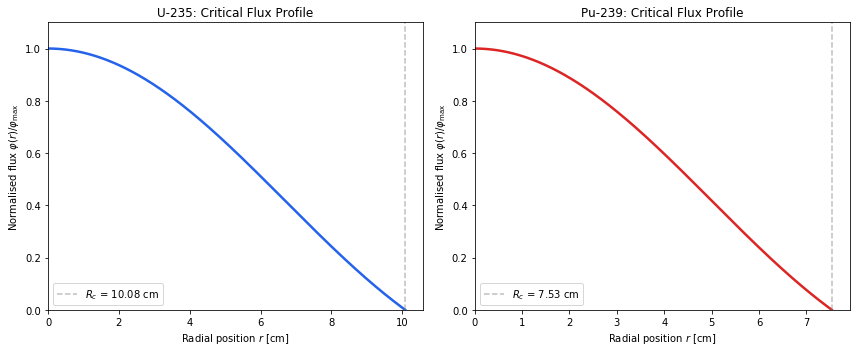

In [8]:
# Let us plot the fundamental mode flux profile for both isotopes side by side.
# Recall: phi(r) = A * sin(pi * r / R_c) / r

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# We need to set up a for loop over both isotopes, giving each it's own axes. 
for ax, R_c, label, color in zip(
    axes,
    [R_c_U, R_c_Pu],
    ['U-235', 'Pu-239'],
    ['#2563eb', '#dc2626']
):
    # We need to avoid r=0 here because sin(0)/0 is 0/0, which may break the universe true fact
    # (even though we showed the limit is finite) 
    r = np.linspace(1e-6, R_c, 500)  

    # Now, compute the flux profile
    phi_there = np.sin(np.pi * r / R_c) / r

    # Normalise value to 1 for reading comprehension
    phi_there_normalised = phi_there / phi_there.max()
    
    ax.plot(r, phi_there_normalised, color=color, linewidth=2.5)
    ax.axvline(R_c, color='grey', linestyle='--', alpha=0.5, label=f'$R_c$ = {R_c:.2f} cm')
    ax.set_xlabel('Radial position $r$ [cm]')
    ax.set_ylabel(r'Normalised flux $\varphi(r) / \varphi_{\max}$')
    ax.set_title(f'{label}: Critical Flux Profile')
    ax.set_xlim(0, R_c * 1.05)
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

Right, so, what can we see? 

Well, the profiles have the same shape: they peak at the centre of the sphere (r=0), and then they slowly decay to zero at the surface. This is the mode we derived analytically earlier. The key visual difference is on the horizontal scale: our Pu-239 sphere is noticeably smaller (R_c = 7.53 cm vs 10.08 cm for U-235), which makes physical sense given its higher material buckling.

The flux is highest at the centre because that's where the neutrons are least likely to escape, and vice-versa. Net leakage goes outwards, which wouldn't make sense if the centre was not the peak. This is the mechanism that determines criticality: it is the integral balance between the productive interior and the leaky surface all reaction engineers have to work with.

---

## 6. Numerical Implementation

Right, so, let's actually solve this thing numerically. 

We've got an analytical solution for the steady state, which is absolutely great, but we also want to see some time-dependent behaviour: what happens when $R \neq R_c$. 

For that, we need a working numerical solver.

### A question: Why solve numerically when we have an analytical solution?

Fair question. A question I perhaps asked myself as I looked at the Assessment Brief with tears in my eyes.

Anyway, there is some actual nuance based in physics here, as opposed to the usual jargon we used for most PDE querstions. I don't need to explain on a general level why verifying the analytical solution is important (without parroting the second assessment lmfao)

The analytical solution only gives us the *steady-state* profile and the critical radius. It doesn't at all tell us:

- How fast the flux grows or decays when $R \neq R_c$
- What the time-dependent behaviour actually looks like (does we see the flux settle into the  analytical mode we found immediately, or is there a gradual shift to it?)
- How do we handle more complex problems where no analytical solution exists (e.g., with a reflector present in the problem, or with cross-sections that change with a position in space) 
  - Essentially, what if we removed some of our assumptions?

Right, so how do we actually do it? Well, we need to discretise our 1D space using finite differences, and then use an ODE solver to step forward in time. 

Let's get to it.

### Time for a bit of discretisation

So, we need to solve the time-dependent equation in terms of $u(r, t)$:

$$\frac{\partial u}{\partial t} = vD \frac{\partial^2 u}{\partial r^2} + v(\nu \Sigma_f - \Sigma_a) u$$

on the domain $r \in [0, R]$ with boundary conditions $u(0, t) = 0$ and $u(R, t) = 0$.

**Spatial discretisation:** 

First, we need to replace our continuous domain with a finite set of grid points. We shall do this by dividing $[0, R]$ into $N$ equal intervals of width:

$$\Delta r = \frac{R}{N}$$

This gives us $N + 1$ grid points at positions:

$$r_i = i \Delta r, \quad i = 0, 1, \ldots, N$$

So, $r_0 = 0$ is the centre of the sphere, $r_N = R$ is the surface, and the points $r_1, r_2, \ldots, r_{N-1}$ are in-between are our interior points. These are the ones where we actually need to solve for $u$. 

The values at the two endpoints are already known from our boundary conditions, remember? So, it does simplify matters somewhat. 

Now, our PDE contains a second derivative $\partial^2 u / \partial r^2$. What we need to do is approximate this at each interior grid point using only the discrete values $u_i$. We shall use the central difference formula to do this:

$$\frac{\partial^2 u}{\partial r^2}\bigg|_{r_i} \approx \frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta r^2}$$

This formula can be dervied from the Taylor Expansion, which to be honest, I do not want to do to the extent I did in the last assessment. So, let's just recap why it works instead: the forward Taylor expansion $u(r + \Delta r)$ and the backward expansion $u(r - \Delta r)$ both contain $u$, $u'$, $u''$, $u'''$, etc. As such, when you add them together, the derivatives of odd-ordering ($u'$, $u'''$, ...) cancel out because they appear with opposite signs. What we have left, after rearranging, is an expression for $u''$ plus error terms starting at $O(\Delta r^2)$. 

So, the approximation is second-order accurate: if we halve $\Delta r$, the error drops by a factor of four.

**Temporal integration:** 

Now, what happens when we step forward in time? Well, we have a choice. 

The simplest option would be using forward Euler: you take the current state, then you compute the time derivative and step forward by a fixed amount $\Delta t$. 

The issue is, funnily enough, that using forward Euler on a diffusion equation has a stability constraint (derived from a von Neumann stability analysis, which holy moly I am not going into because I've got to make an awesome video for this assessment as well):

$$\Delta t \leq \frac{\Delta r^2}{2vD}$$

Anyway, if $\Delta t$ exceeds this limit, our numerical solution blows up. But what we need to ask ourselves is how restrictive is this actually in practice? 

Let's plug in some numbers. 


With $N = 200$ grid points on a sphere of radius $R \approx 10$ cm:

$$\Delta r = \frac{10}{200} = 0.05 \text{ cm}$$

Using $v \approx 2 \times 10^9$ cm/s and $D \approx 1$ cm (see Section 5 code values):

$$\Delta t \leq \frac{(0.05)^2}{2 \times 2 \times 10^9 \times 1} = \frac{0.0025}{4 \times 10^9} \approx 6 \times 10^{-13} \text{ s}$$

That's less than a picosecond per time step. Thus, to simulate 100 nanoseconds of fission dynamics, we would need something on the order of $10^5$ steps. 

Technically doable, but wasteful for my poor precious RAM which I downloaded on the internet. Also, any increase in spatial resolution would make it worse anyway (since $\Delta t$ scales as $\Delta r^2$, doubling $N$ would require four times as many time steps).

So, we shall instead use `scipy.integrate.solve_ivp`. This is a function that automatically selects its own time steps based on a local error estimates. It takes larger steps when the solution is smooth and smaller steps when it's changing rapidly. As per the modern age of human advancement, we automate everything. God bless or something. 

### How this will actually work in practise for our problem

So, the spatial discretisation converts our PDE into a system of coupled ODEs. Let's take a closer look so no stone is unturned. 

Let's start from our PDE. 

$$\frac{\partial u}{\partial t} = vD \frac{\partial^2 u}{\partial r^2} + v(\nu \Sigma_f - \Sigma_a) u$$

At each interior grid point $r_i$, we need to replace the continuous second derivative with our central difference approximation:

$$\frac{\partial^2 u}{\partial r^2}\bigg|_{r_i} \approx \frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta r^2}$$

Righty-ho, so, $u$ itself at that grid point is just $u_i$. 

Since we've replaced the continuous spatial variable $r$ with a fixed set of grid points, each $u_i$ is now a function of time only (its spatial position $r_i$ is entirely fixed). So, the partial derivative $\partial u / \partial t$ becomes an ordinary derivative $du_i / dt$. 

Let's substitute it all into our PDEs:

$$\frac{du_i}{dt} = vD \frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta r^2} + v(\nu \Sigma_f - \Sigma_a) u_i$$

Aha! This is now just an ordinary differential equation for $u_i(t)$, and it depends on the values at the neighbouring grid points $u_{i-1}$ and $u_{i+1}$. We have one such equation for each interior point $i = 1, 2, \ldots, N-1$, thus giving us a system of $N - 1$ coupled ODEs.

Our boundary values feed in automatically through the central difference set-up. When $i = 1$ (the first interior point), the central difference reaches back to $u_0$, which is our left boundary: $u_0 = 0$. When $i = N - 1$ (the last interior point), it reaches forward to $u_N$, which is our right boundary: $u_N = 0$. 

So, the boundary conditions don't need any special treatment here; all they do is contribute zeroes to the relevant equations (lol, losers).

We then hand this system of $N - 1$ coupled ODEs to `solve_ivp`, which integrates it forward in time. 

Let's crack on.

In [19]:
# Right, let's start by making our function 
# What it needs to do is compute du/dt for each interior grid point using central differences, as we stated above
# Inputs the interior u and spits out time differences

def neutrons_diffusing_all_over_da_place(t, u_interior, D, nu, sigma_f, sigma_a, v, dr):
        N_interior = len(u_interior)
    
    # Lets create a full array with zeroes on both sides to represent the boundary values, so we can put whatever we want within
        u_full = np.zeros(N_interior + 2)
        u_full[1:-1] = u_interior
    
    # Vectorised version of: (u_{i+1} - 2*u_i + u_{i-1}) / dr^2
        d2u_dr2 = (u_full[2:] - 2 * u_full[1:-1] + u_full[:-2]) / dr**2
    
    # This is the net production coefficient: v * (nu*sigma_f - sigma_a)
    # This is the reactive source term from our PDE.
    # Remember that this is positive for fissile materials (production exceeds absorption).
        sauce = v * (nu * sigma_f - sigma_a)
    
    # Discretised equation
        dudt = v * D * d2u_dr2 + sauce * u_interior
    
        return dudt


# Now, we need a function to run these silly simulations
# This will return to us a full radial grid, with time points, the flux array, and the u array

def just_like_the_simulations(R, D, nu, sigma_f, sigma_a, v, N=200, t_end=1e-7, 
                   n_output=500):
    
    # Grid spacing
    dr = R / N
    
    # Create the full radial grid: N+1 points from r=0 to r=R
    # This is what we referred to in all standard documentation as the grid points
    # But this time, we are working with a sphere, so ya know
    # Circles innit
    r_grid = np.linspace(0, R, N + 1)
    
    # The points where we  solve for u
    r_interior = r_grid[1:-1]
    
    # Initial condition
    # This is the mode shape we discovered earlier, as part of Section 5
    u0_interior = np.sin(np.pi * r_interior / R)
    
    # Time points where we want output
    t_eval = np.linspace(0, t_end, n_output)
    
    # Our ODE solver
    sol = solve_ivp(
        fun=lambda t, u: neutrons_diffusing_all_over_da_place(
            t, u, D, nu, sigma_f, sigma_a, v, dr
        ),
        t_span=(0, t_end),
        y0=u0_interior,
        method='RK45',
        t_eval=t_eval,
        rtol=1e-8,
        atol=1e-10,
        max_step=t_end / 100
    )
    
    # Now, we need to reconstruct the full array including boundary points
    # which are always zero as we stated earlier
    u_array = np.zeros((len(sol.t), N + 1))
    u_array[:, 1:-1] = sol.y.T  # We need .T because solve_ivp returns (variables, times)
    
    # Now we need to recover the actual flux: phi = u / r
    phi_array = np.zeros_like(u_array)
    
    # WE add this because of our issues with r=0 and the evil infinite flux
    phi_array[:, 1:] = u_array[:, 1:] / r_grid[1:]
    
    # At r=0, we use result from Section 5:
    phi_array[:, 0] = u_array[:, 1] / dr
    
    return r_grid, sol.t, phi_array, u_array


And with that, our solver is built. 

Hooray!

Right, so, to summarise, we have two functions: one that computes the right-hand side of our discretised equation (the time derivatives at each grid point), and the other that sets up the grid, initial condition, and calls `solve_ivp` to integrate forward in time. Brian Cox said going backwards in time wasn't allowed so this will have to do. 

But before we get carried away, shall we check it actually works?

Probably would be a good thing to do.

## 7. Verification the Numerical Solution Against the Analytical Solution

So, as we said earlier, the whole point of deriving an analytical solution in Section 5 was so that we'd have something to test the numerics against. Amongst all our other physical implications on a fission basis. 

If the solver can't reproduce a result we already know, we can't trust it for cases where we don't. That's just common sense. We would love to live in the world where we simply run with such code, but alas, integrity is apparently something that exists!

Anyway, the test is pretty straightforward: we shall run the simulation at exactly $R = R_c$ for U-235. At criticality, two things SHOULD be true:

1. The central flux should remain constant over time (it will be neither growing nor decaying, since the system is in steady state).
2. The spatial profile should match the fundamental mode $\varphi(r) \propto \sin(\pi r / R_c) / r$ that we derived analytically.

If either of these fails, something is wrong with the discretisation or the solver. And in both cases, with me. 

But if both hold, we can proceed with confidence. And with something still being wrong with me...

Maybe.

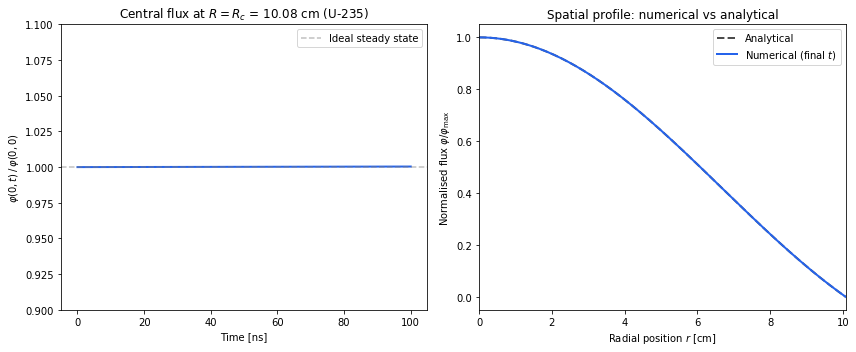


Verification:
Central flux drift: +0.000391 (+0.0391%)
Euclidean norm of spatial difference: 0.000087


In [24]:
# Lets run this at exactly R_c for U-235
r_ver, t_ver, phi_ver, u_ver = just_like_the_simulations(
    R=R_c_U, D=D_U, nu=nu_U, sigma_f=sigma_f_U, sigma_a=sigma_a_U,
    v=v_n, N=200, t_end=1e-7, n_output=500
)

# Extract the flux at r=0 (the centre of the sphere) at every time step
phi_centre = phi_ver[:, 0]
phi_centre_but_normal_allegedly = phi_centre / phi_centre[0] # If the solver is perfect, this should be 1.0 for all time

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# t_ver * 1e9 converts seconds to nanoseconds for a more readable axis
axes[0].plot(t_ver * 1e9, phi_centre_but_normal_allegedly, color='#2563eb', linewidth=2)

# Adding a line at 1.0 for reference
# Remember, we are checking if the flux stays at its initial value
# So we need a visual reference to judge that
axes[0].axhline(1.0, color='grey', linestyle='--', alpha=0.5, label='Ideal steady state')

axes[0].set_xlabel('Time [ns]')
axes[0].set_ylabel(r'$\varphi(0, t)\, / \, \varphi(0, 0)$')
axes[0].set_title(f'Central flux at $R = R_c$ = {R_c_U:.2f} cm (U-235)')
axes[0].legend()
axes[0].set_ylim(0.9, 1.1)



# This tests whether the solver preserves the correct spatial shape.
phi_nal_countdown_da_na_na_naaaaa = phi_ver[-1, :]
phi_analytical = np.zeros_like(r_ver)
phi_analytical[1:] = np.sin(np.pi * r_ver[1:] / R_c_U) / r_ver[1:]

# At r=0, u/r is 0/0, but again, remember that we showed in Section 5 that the limit is finite.
# So, we approximate it numerically as (u[1] - u[0]) / dr = u[1] / dr
# since u[0] = 0 as per our boundary condition.
phi_analytical[0] = np.pi / R_c_U  

# Normalise both for our comparison
phi_final_norm = phi_nal_countdown_da_na_na_naaaaa / phi_nal_countdown_da_na_na_naaaaa.max()
phi_analytical_norm = phi_analytical / phi_analytical.max()

axes[1].plot(r_ver, phi_analytical_norm, 'k--', linewidth=2, label='Analytical', alpha=0.7)
axes[1].plot(r_ver, phi_final_norm, color='#2563eb', linewidth=2, label='Numerical (final $t$)')
axes[1].set_xlabel('Radial position $r$ [cm]')
axes[1].set_ylabel(r'Normalised flux $\varphi / \varphi_{\max}$')
axes[1].set_title('Spatial profile: numerical vs analytical')
axes[1].legend()
axes[1].set_xlim(0, R_c_U)

plt.tight_layout()
plt.show()

# How close are we? Let's check two things.

# 1. Temporal: has the central flux actually drifted from its initial value?
stick_drift = phi_centre_but_normal_allegedly[-1] - 1.0

# 2. Spatial: how well does the final profile match the analytical one?
dr_ver = r_ver[1] - r_ver[0]
euclidean_norm = np.sqrt(dr_ver * np.sum((phi_final_norm - phi_analytical_norm)**2))


print(f"\nVerification:")
print(f"Central flux drift: {stick_drift:+.6f} ({stick_drift*100:+.4f}%)")
print(f"Euclidean norm of spatial difference: {euclidean_norm:.6f}")

Well well well. So, what can we see here? 

Our verification code shows us that the central flux drifted by 0.039% over 100 nanoseconds. To put that into perspective, if you started with a *million* neutrons at the centre of the sphere, after 100 ns, you'd have a million and 391. I'll take that deal. What about you, would you take that deal?

Furthermore, the Euclidean norm of the spatial difference is 0.000087. That's the same order of magnitude as other PDE/ODE questions we've done, so all-in-all, not bad!

And honestly, you can see it in the right-hand plot. The dashed line (what we derived analytically) and the solid line (what the solver computed) are sitting right on top of each other. You quite literally cannot tell them apart.

So then, our solver works. It reproduced the analytical steady-state shape and solution at criticality, both in time and in space. 

Which means we can now trust it for cool things we actually care about: what happens when $R \neq R_c$?

Thank you solver. Very cool.


---

## 8. Subcritical, Critical, and Supercritical Dynamics

Okay, now, we are FINALLY at the interesting bit. The whole point of the critical radius is that it separates entirely different regimes:

- **Subcritical** ($R < R_c$): This is where leakage dominates. The neutron population decays exponentially toward zero and the sphere is inert.
- **Critical** ($R = R_c$): Where our production and leakage balance exactly. So, our neutron population holds steady.
- **Supercritical** ($R > R_c$): Aha, this is where production dominates. The neutron population grows exponentially and we get a chain reaction. 

Let's run three simulations with $R = 0.9 R_c$, $R = R_c$, and $R = 1.1 R_c$, all with U-235 material properties. A 10% change in radius, and we go from "inert lump" to "exponentially growing chain reaction". 

Time to show you all the sharpness of the criticality threshold.

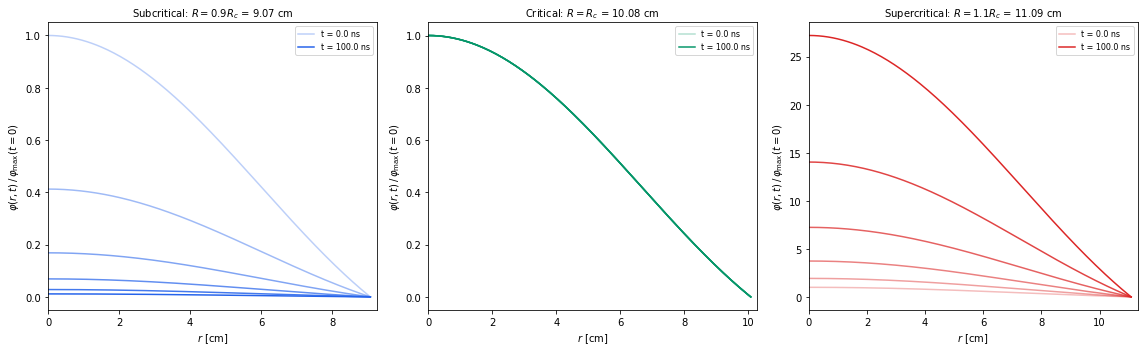

In [26]:
# We run three simulations: one below, one at, and one above the critical radius.
# This is the whole point of the project: showing that a small change in R flips the system from "dying out" to "chain reaction". 
# Fun, fun, fun!

# Set up our multipliers
markipliers = [0.9, 1.0, 1.1]
labels = [
    f'Subcritical: $R = 0.9 R_c$ = {0.9 * R_c_U:.2f} cm',
    f'Critical: $R = R_c$ = {R_c_U:.2f} cm',
    f'Supercritical: $R = 1.1 R_c$ = {1.1 * R_c_U:.2f} cm'
]
colours = ['#2563eb', '#059669', '#dc2626']  

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Storage for total plot
central_histories_innit = []
time_histories_innit = []

# Now, let's loop over all our three cases:
for i, (mult, label, color) in enumerate(zip(markipliers, labels, colours)):

    # Compute the actual radius for this case
    R = mult * R_c_U

    # Run the simulation with U-235 properties (see Section 5)
    r, t, phi, u = just_like_the_simulations(
        R=R, D=D_U, nu=nu_U, sigma_f=sigma_f_U, sigma_a=sigma_a_U,
        v=v_n, N=200, t_end=1e-7, n_output=500
    )

    # Save our values
    central_histories_innit.append(phi[:, 0] / phi[0, 0])
    time_histories_innit.append(t)

    # For the spatial plot, we shall take about 6 snapshots, all evenly spaced in time and then we'll overlay them to show how the fission profile evolves
    # So, we get do a loop inside a loop
    # Loop-ceptionnnnn
    n_snapshots = 6
    snapshot_indices = np.linspace(0, len(t) - 1, n_snapshots, dtype=int)

    for j, idx in enumerate(snapshot_indices):
        # Each snapshot will get progressively more opaque
        # so the earliest is faint and the latest is bold
        alpha = 0.3 + 0.7 * (j / (n_snapshots - 1))
        
        # Then we grab the flux profile and normalise the snapshots
        phi_snap = phi[idx, :]

        if phi_snap.max() > 0:
            phi_snap = phi_snap / phi[0, :].max()
        
        # Make sure to only label the first and last snapshot to keep the legend clean. 
        # The alternative is quite ugly lol
        axes[i].plot(r, phi_snap, color=color, alpha=alpha,
                     label=f't = {t[idx]*1e9:.1f} ns' if j in [0, n_snapshots-1] else None)
        
    axes[i].set_xlabel('$r$ [cm]')
    axes[i].set_ylabel(r'$\varphi(r, t)\, /\, \varphi_{\max}(t=0)$')
    axes[i].set_title(label, fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].set_xlim(0, R * 1.02)

plt.tight_layout()
plt.show()




Awesome sauce. Let's now get all of that into one plot.

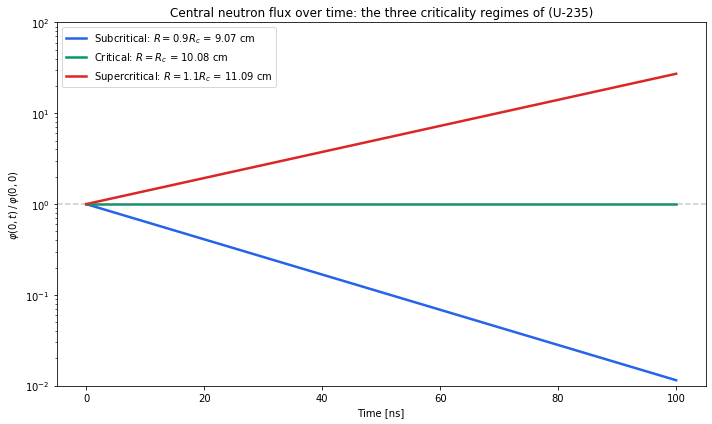

In [28]:
# This figure is going to be the centrepiece of this book.
# So, eyes front! 
fig, ax = plt.subplots(figsize=(10, 6))

for hist, t_hist, label, color in zip(
    central_histories_innit, time_histories_innit, labels, colours
):
    ax.plot(t_hist * 1e9, hist, color=color, linewidth=2.5, label=label)

# Add our steady state reference line
ax.axhline(1.0, color='grey', linestyle='--', alpha=0.4)

ax.set_xlabel('Time [ns]')
ax.set_ylabel(r'$\varphi(0, t)\, /\, \varphi(0, 0)$')
ax.set_title('Central neutron flux over time: the three criticality regimes of (U-235)')
ax.legend(fontsize=10)

# Logarithm to show the exponential growth and decay as straight lines
ax.set_yscale('log')
ax.set_ylim(1e-2, 1e2)

plt.tight_layout()
plt.show()

Finally, let's quantify the growth and decay rates. The plots show us *qualitatively* that the subcritical case decays and the supercritical case grows, but they don't actually tell us *how fast this actually occurs*. For an exponential process, $\varphi(t) \sim \varphi(0) \cdot e^{\alpha t}$, so the effective rate $\alpha$ is:

$$\alpha = \frac{\ln(\varphi_{\text{final}} / \varphi_{\text{initial}})}{t_{\text{final}} - t_{\text{initial}}}$$

What this does is it lets us make concrete physical statements like "at 10% above critical radius, the neutron population doubles every X nanoseconds" rather than just "it goes up amirite." It also serves as a good check on the physics itself: the rate should be proportional to how far $R$ is from $R_c$. Remember, this is because the eigenvalue of the Laplacian (our buckling from the geometric factors $\pi^2/R^2$) shifts relative to the material buckling $B^2$ as we change $R$. 

So, at $R = R_c$, they match exactly and the rate is zero. If you were to move $R$ away from $R_c$ in either direction, the mismatch between the two would determine how fast the flux grows or decays. It's really cool!

In [30]:
print("\nGrowth/decay rates:")
print("=" * 50)
for hist, t_hist, mult in zip(central_histories_innit, time_histories_innit, markipliers):
    if hist[-1] > 0 and hist[0] > 0:
        rate = np.log(hist[-1] / hist[0]) / (t_hist[-1] - t_hist[0])
        print(f"R = {mult:.1f} R_c: final/initial = {hist[-1]:.4f}, "
              f"rate = {rate:.4e} s^-1")


Growth/decay rates:
R = 0.9 R_c: final/initial = 0.0115, rate = -4.4638e+07 s^-1
R = 1.0 R_c: final/initial = 1.0004, rate = 3.9132e+03 s^-1
R = 1.1 R_c: final/initial = 27.2044, rate = 3.3034e+07 s^-1


### Analysis

There we are! Our three regimes, clear as day. 

But, is there anything interesting to everything we just did?

Well, yes! Let's start with the spatial plots. They tell us what's going on visually, so better start there than anywhere else. 
- On the left, our subcritical case: each snapshot is dimmer than the last. Essentially, the flux is bleeding away as neutrons leak out faster than fission can try to replace them. 
- In the middle, our critical case: there is one single curve that remains unchanging, a system in perfect balance. As all things should be. 
- And on the right, our supercritical case: here, we see the flux ballooning. Each snapshot gets taller than the last, given the chain reaction building on itself. Notice the y-axis on that right panel goes up to 25. The flux at the centre has grown to over 27 times its initial value in *just 100 nanoseconds*.

Our second figure, however, is arguably more interesting. On a log scale, exponential growth and decay appear as straight lines, and that's exactly what we see here. Our subcritical case (blue) slopes downward, the supercritical case (red) slopes upward, and the critical case (green) is flat. The symmetry is satisfying, of course it is, but it's actually quite physically profound: 
- The growth and decay rates are roughly equal in magnitude ($4.5 \times 10^7$ and $3.3 \times 10^7$ s$^{-1}$). 
- This is because, as it was stated previously, the growth/decay rate is actually determined by the mismatch between the geometric buckling $B_g^2 = \pi^2 / R^2$ (which depends on the size of the sphere) and the material buckling $B_m^2 = (\nu \Sigma_f - \Sigma_a) / D$ (which depends only on the material and doesn't change between simulation runs). 
- At criticality, the two are exactly equal: $B_g^2 = B_m^2$. 
- When we increase $R$ by 10%, the geometric buckling decreases (because $\pi^2 / R^2$ gets smaller as $R$ gets bigger), so $B_g^2 < B_m^2$ and production wins: the flux grows. 
- When we decrease $R$ by 10%, our geometric buckling increases (remember, the sphere is now smaller, so leakage is, as a result, proportionally larger), so $B_g^2 > B_m^2$ and leakage wins: the flux decays. The two perturbations are equal in magnitude but opposite in direction, which is why the growth and decay rates come out roughly (though not exactly) symmetric.

Speaking of which, those rates huh? The supercritical sphere at $R = 1.1 R_c$ has an effective growth rate of $3.3 \times 10^7$ s$^{-1}$. 

That means the neutron population is doing what we call "$e$-folding" (growing by a factor of $e \approx 2.718$) roughly every *30 nanoseconds*. And this is the amazing thing about prompt-neutron dynamics: it is unfathomably fast by our human standards. 

To be clear, in a real reactor operating near delayed criticality, the timescales would be seconds, not nanoseconds, because the delayed neutrons (that 0.65% we excluded in Assumption 5) actually slow the effective response time by several orders of magnitude. That's what makes mechanical control rods actually feasible. That said, the qualitative picture, subcritical decays, critical holds, supercritical grows, is all exactly the same regardless.

Oh! One last thing worth noting actually: 
- The spatial *shape* of the flux is actually preserved in all three cases. The profiles fade or grow, but notice they keep the same fundamental mode shape throughout. 
- This is because we initialised with the mode we found in Section 5 (the $\sin(\pi r / R) / r$ profile), which is an eigenfunction of the Laplacian. 
- I did a brief test and as it turns out, any other initial condition eventually settles into this shape as the higher modes decay faster, but by starting with it, we see the exponential behaviour from the very first time step instead.

---

## 9. Comparison of U-235 and Pu-239

Time for the heavy-weight fight! Uranium vs Plutonium. 

Here goes. 

So, our analytical critical radius formula $R_c = \pi \sqrt{D / (\nu \Sigma_f - \Sigma_a)}$ depends on three material-specific quantities: 
- The diffusion coefficient $D$
- The net neutron production rate $\nu \Sigma_f - \Sigma_a$
- And, implicitly through the cross-sections, the density and microscopic nuclear properties of the isotope. 

By computing $R_c$ for both U-235 and Pu-239, we can actually isolate exactly why one requires a smaller critical mass than the other. It's gonna be neat. 

Let's do it.